<a href="https://colab.research.google.com/github/Fardous-bp/Physics-Informed-ML-for-Silicon-Solar-Cell-Optimization/blob/main/Si_solar_cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Voc = 0.597 V
FF  = 0.802
Efficiency = 19.15 %


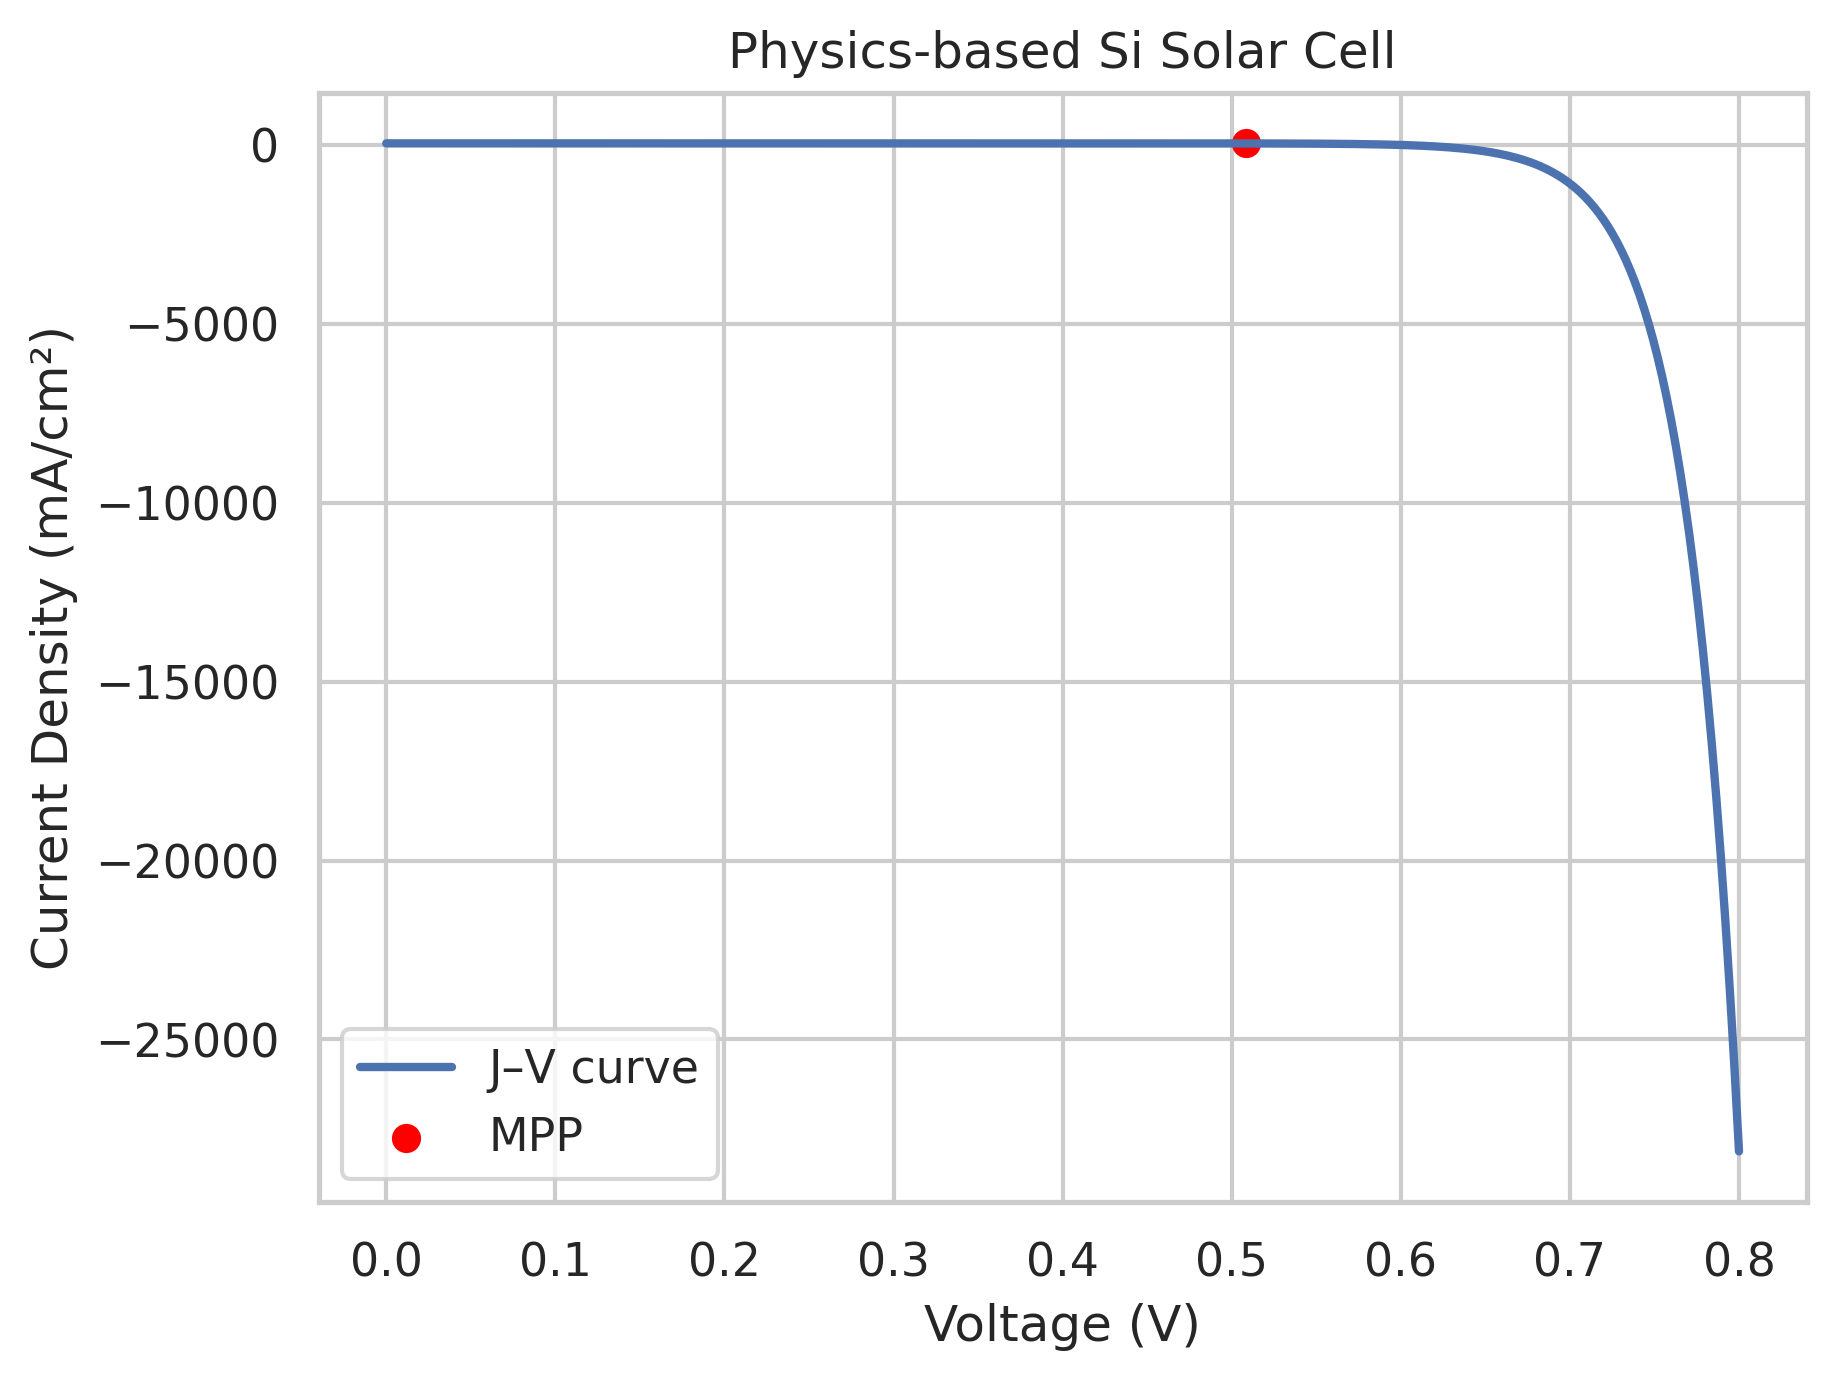

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Physical constants
# -----------------------------
q = 1.602e-19       # Charge (C)
k = 1.381e-23       # Boltzmann constant (J/K)
T = 300             # Temperature (K)
ni = 1.0e10         # Intrinsic carrier concentration (cm^-3)

# -----------------------------
# Device parameters (baseline)
# -----------------------------
Nd = 1e16           # Base doping (cm^-3)
tau_bulk = 1e-3     # Bulk lifetime (s)
S = 1e3             # Surface recombination velocity (cm/s)
W = 180e-4          # Wafer thickness (cm)

Jph = 40e-3         # Photocurrent density (A/cm^2)
n = 1.2             # Ideality factor

# -----------------------------
# Effective lifetime
# -----------------------------
tau_eff = 1 / (1/tau_bulk + 2*S/W)

# -----------------------------
# Saturation current density
# -----------------------------
J0 = q * (ni**2) / (Nd * tau_eff)

# -----------------------------
# Voltage range
# -----------------------------
V = np.linspace(0, 0.8, 300)

# -----------------------------
# J–V equation
# -----------------------------
J = Jph - J0 * (np.exp(q * V / (n * k * T)) - 1)

# -----------------------------
# Extract Voc
# -----------------------------
Voc = (n * k * T / q) * np.log(Jph / J0 + 1)

# -----------------------------
# Extract max power point
# -----------------------------
P = V * J
idx = np.argmax(P)
Vmp, Jmp, Pmax = V[idx], J[idx], P[idx]

# -----------------------------
# Fill factor & efficiency
# -----------------------------
FF = Pmax / (Voc * Jph)
Pin = 100e-3        # 1 sun (W/cm^2)
eta = Pmax / Pin

# -----------------------------
# Output results
# -----------------------------
print(f"Voc = {Voc:.3f} V")
print(f"FF  = {FF:.3f}")
print(f"Efficiency = {eta*100:.2f} %")

# -----------------------------
# Plot J–V curve
# -----------------------------
plt.plot(V, J*1e3, label="J–V curve")
plt.scatter(Vmp, Jmp*1e3, color='red', label="MPP")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")
plt.title("Physics-based Si Solar Cell")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import numpy as np
import pandas as pd

# Physical constants
q = 1.602e-19
k = 1.381e-23
T = 300
ni = 1e10

Jph = 40e-3
n = 1.2
Pin = 100e-3

# Parameter ranges (log-spaced where needed)
tau_bulk_list = np.logspace(-6, -2.3, 10)    # 1 us to ~5 ms
S_list = np.logspace(1, 5, 10)                # 10 to 1e5 cm/s
W_list = np.linspace(80e-4, 250e-4, 5)        # 80–250 um
Nd_list = np.logspace(15, 17, 5)               # doping

data = []

for tau_bulk in tau_bulk_list:
    for S in S_list:
        for W in W_list:
            for Nd in Nd_list:

                tau_eff = 1 / (1/tau_bulk + 2*S/W)
                J0 = q * (ni**2) / (Nd * tau_eff)

                Voc = (n * k * T / q) * np.log(Jph / J0 + 1)

                V = np.linspace(0, Voc, 200)
                J = Jph - J0 * (np.exp(q * V / (n * k * T)) - 1)

                P = V * J
                Pmax = np.max(P)

                FF = Pmax / (Voc * Jph)
                eta = Pmax / Pin

                data.append([tau_bulk, S, W*1e4, Nd, Voc, FF, eta])

df = pd.DataFrame(data, columns=[
    "tau_bulk (s)", "S (cm/s)", "W (um)", "Nd (cm^-3)",
    "Voc (V)", "FF", "Efficiency"
])

print(df.head())
print(f"Total samples: {len(df)}")

   tau_bulk (s)  S (cm/s)  W (um)    Nd (cm^-3)   Voc (V)        FF  \
0      0.000001      10.0    80.0  1.000000e+15  0.457066  0.762318   
1      0.000001      10.0    80.0  3.162278e+15  0.492795  0.774241   
2      0.000001      10.0    80.0  1.000000e+16  0.528524  0.784933   
3      0.000001      10.0    80.0  3.162278e+16  0.564253  0.794519   
4      0.000001      10.0    80.0  1.000000e+17  0.599982  0.803219   

   Efficiency  
0    0.139372  
1    0.152617  
2    0.165942  
3    0.179324  
4    0.192767  
Total samples: 2500


Using W = 165.0 um, Nd = 1.00e+16


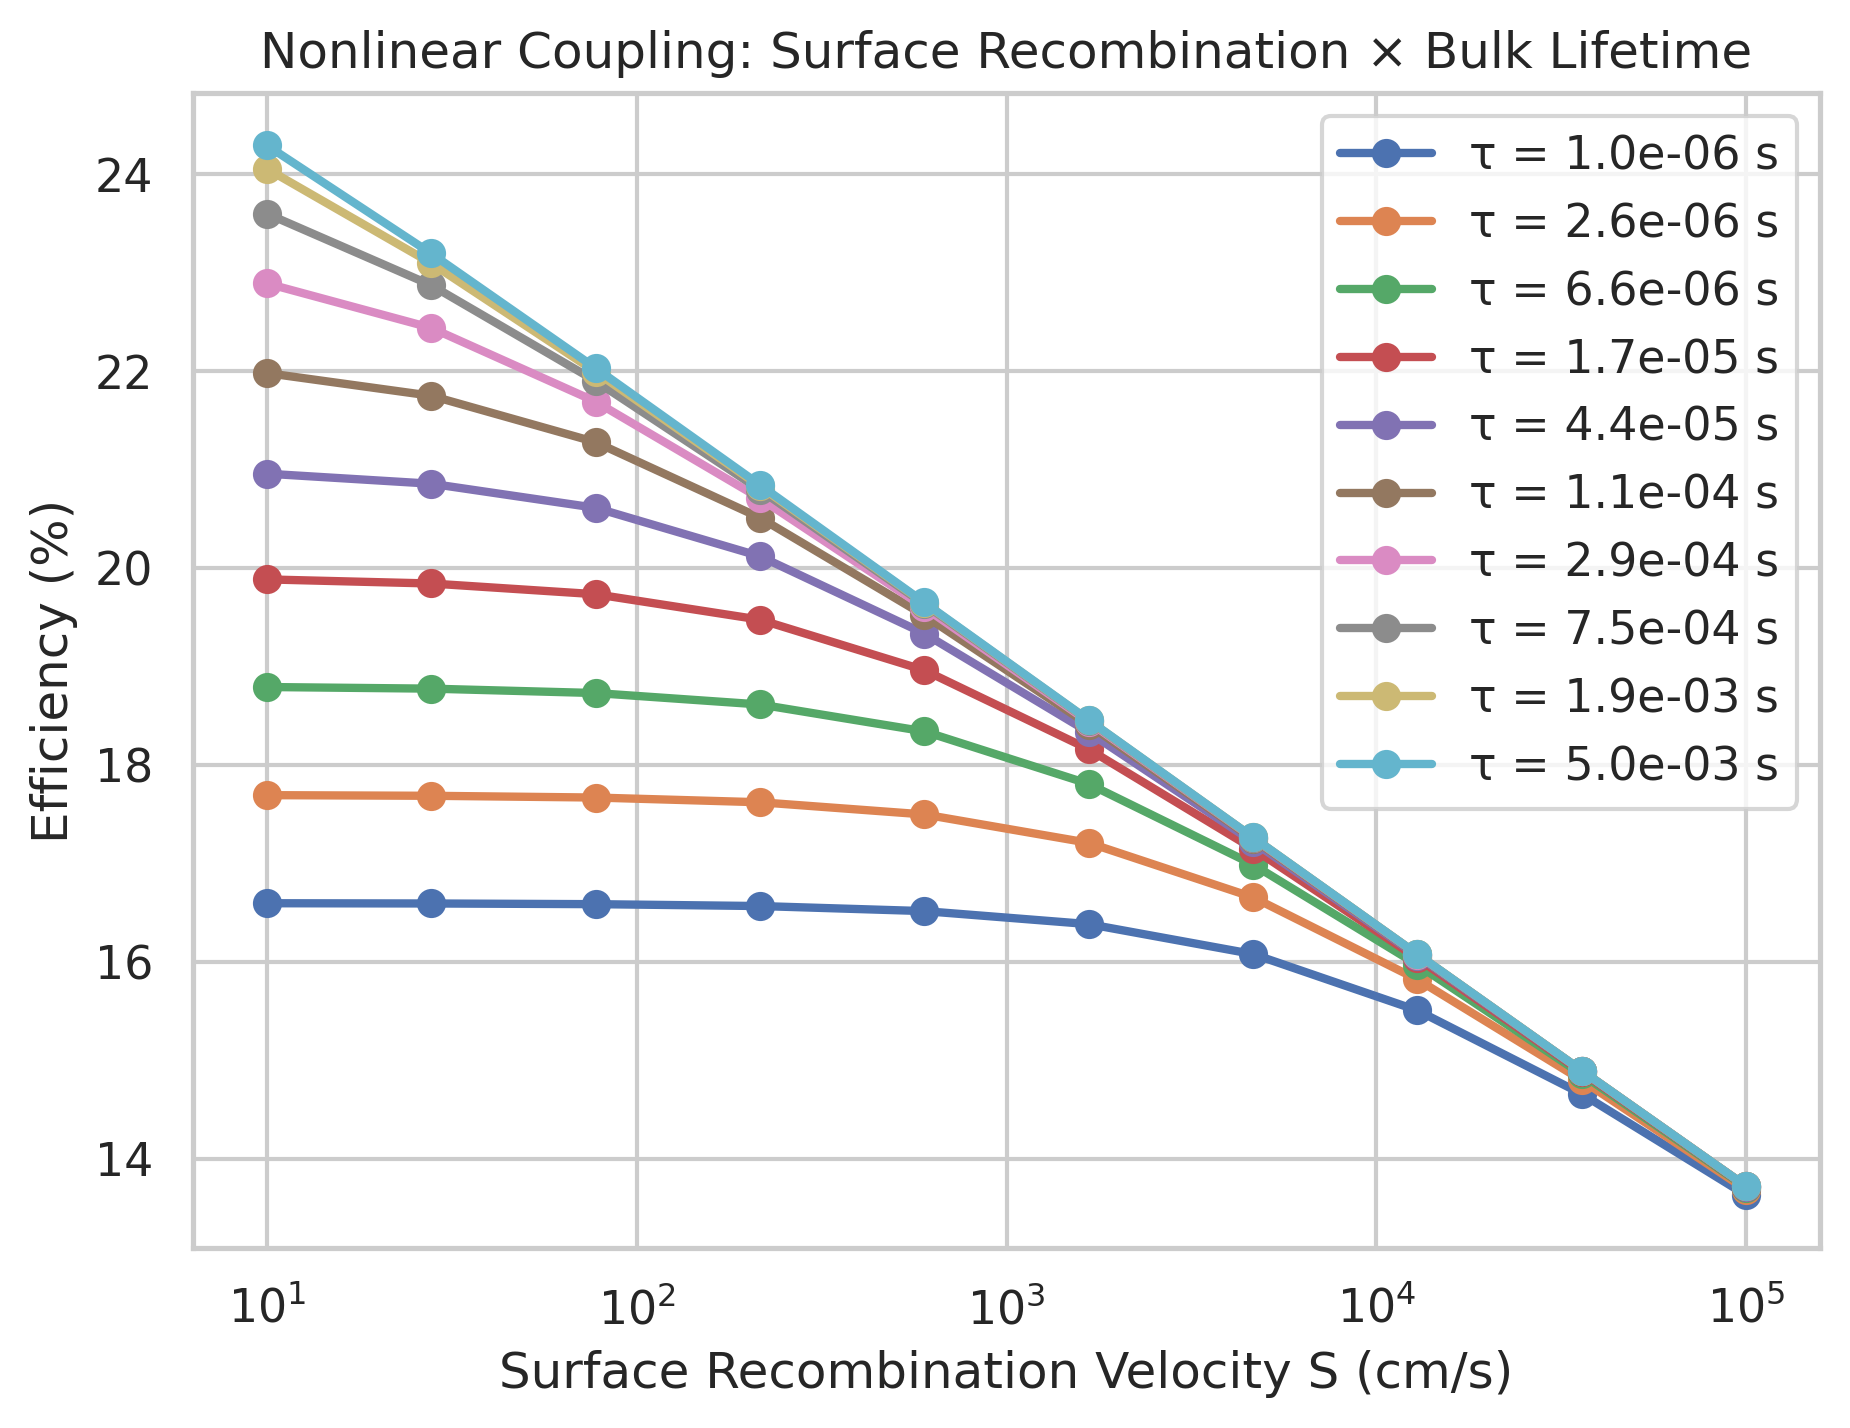

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Find closest W and Nd in the dataset
fixed_W = df["W (um)"].iloc[(df["W (um)"] - 180).abs().argsort()[:1]].values[0]
fixed_Nd = df["Nd (cm^-3)"].iloc[(df["Nd (cm^-3)"] - 1e16).abs().argsort()[:1]].values[0]

subset = df[(df["W (um)"] == fixed_W) & (df["Nd (cm^-3)"] == fixed_Nd)]

print(f"Using W = {fixed_W} um, Nd = {fixed_Nd:.2e}")

plt.figure(figsize=(7,5))

for tau in sorted(subset["tau_bulk (s)"].unique()):
    data_tau = subset[subset["tau_bulk (s)"] == tau]
    plt.semilogx(
        data_tau["S (cm/s)"],
        data_tau["Efficiency"]*100,
        marker='o',
        label=f"τ = {tau:.1e} s"
    )

plt.xlabel("Surface Recombination Velocity S (cm/s)")
plt.ylabel("Efficiency (%)")
plt.title("Nonlinear Coupling: Surface Recombination × Bulk Lifetime")
plt.legend()
plt.grid(True)
plt.show()

R^2 score: 0.999059715923836


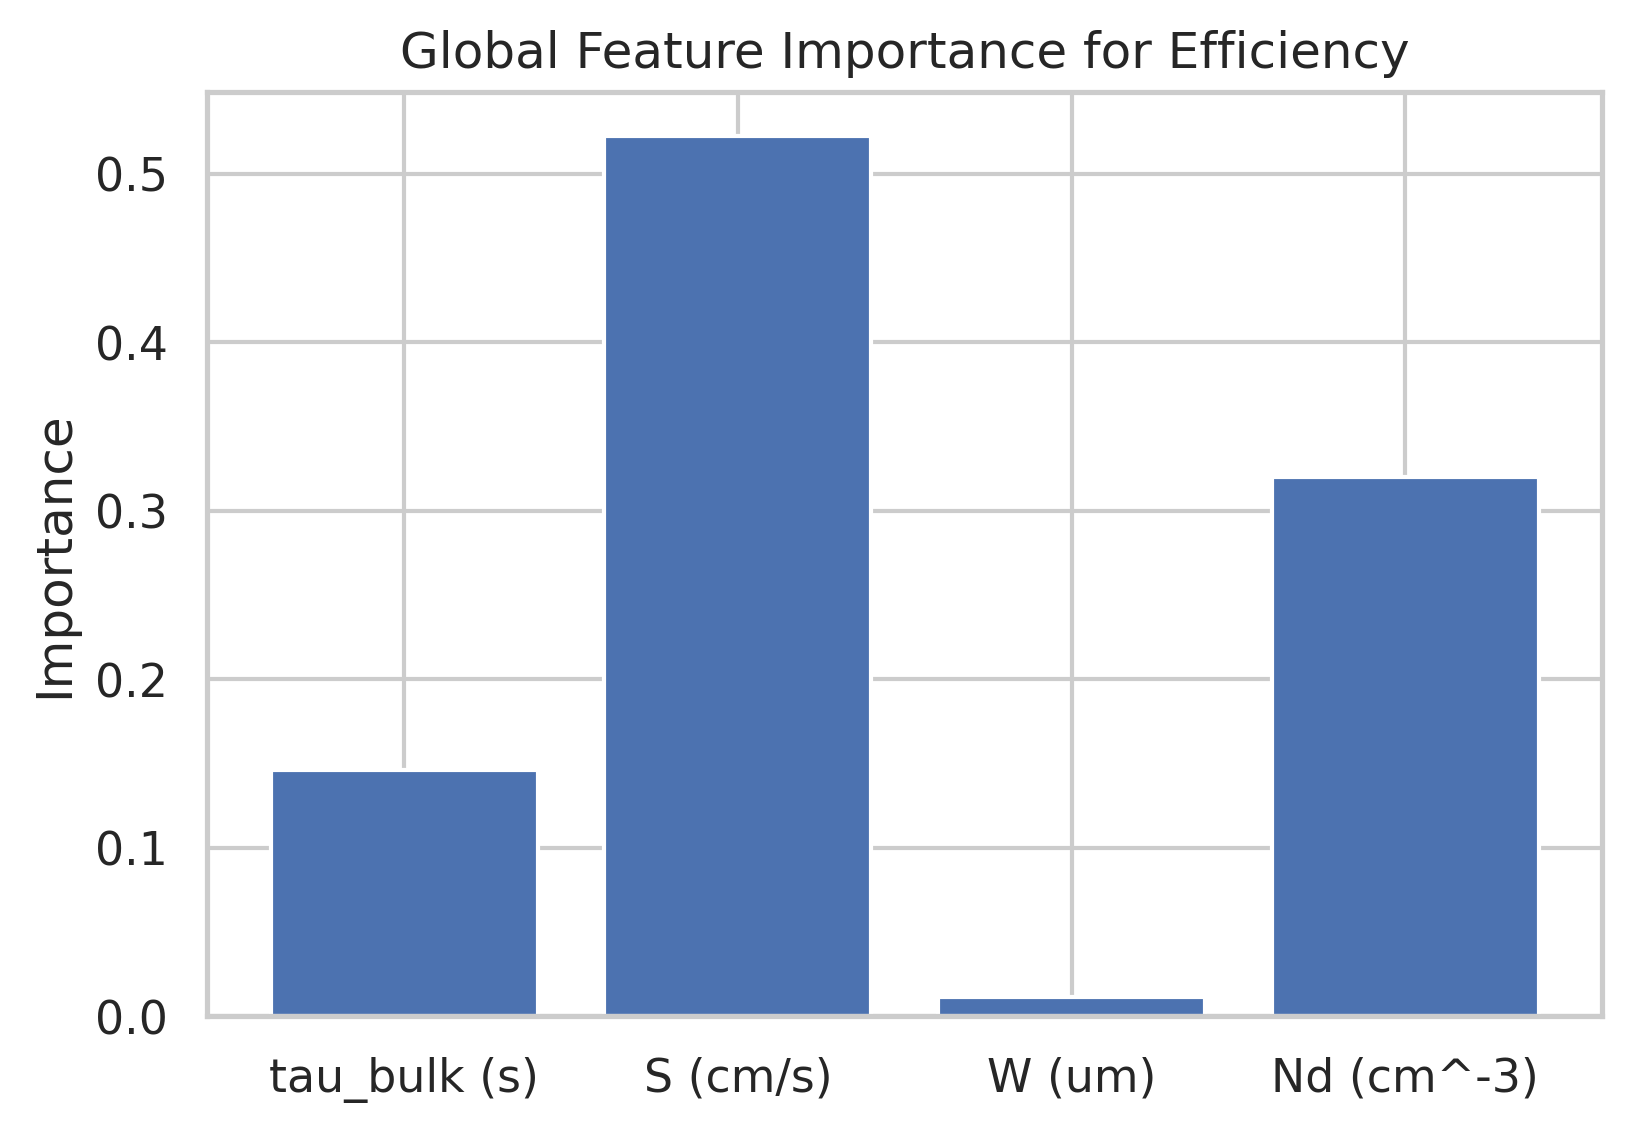

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Features and target
X = df[["tau_bulk (s)", "S (cm/s)", "W (um)", "Nd (cm^-3)"]]
y = df["Efficiency"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Model score
print("R^2 score:", rf.score(X_test, y_test))

# Feature importance
importances = rf.feature_importances_
feat_names = X.columns

plt.figure(figsize=(6,4))
plt.bar(feat_names, importances)
plt.title("Global Feature Importance for Efficiency")
plt.ylabel("Importance")
plt.show()

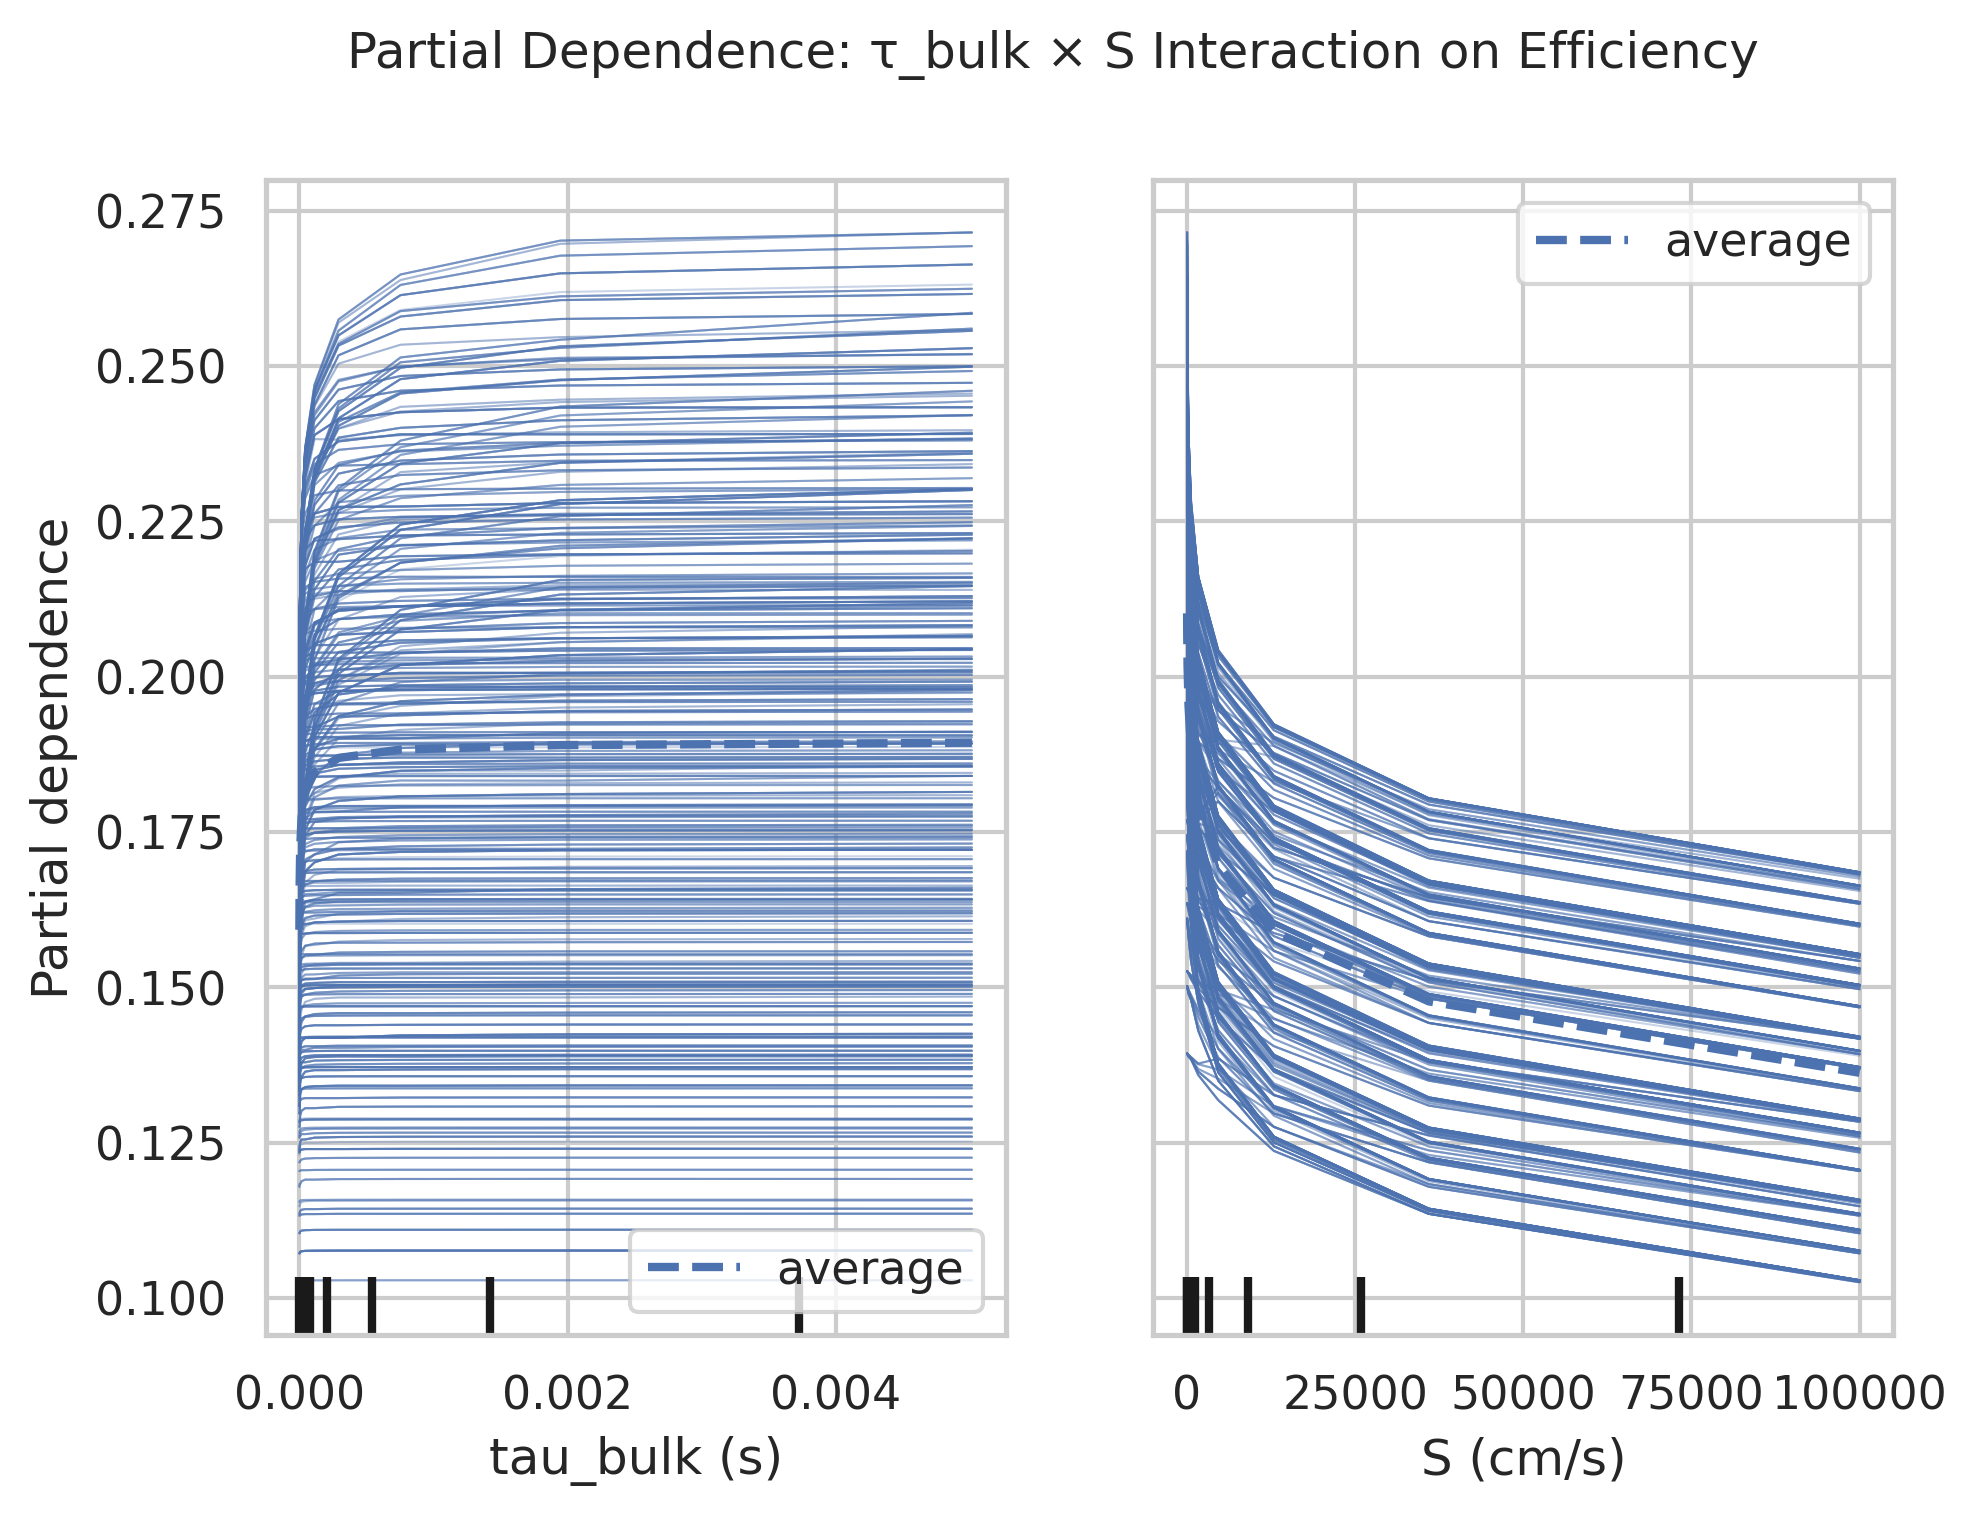

In [15]:
from sklearn.inspection import PartialDependenceDisplay

features = ["tau_bulk (s)", "S (cm/s)"]

# 2D partial dependence plot
fig, ax = plt.subplots(figsize=(7,5))
PartialDependenceDisplay.from_estimator(rf, X, features=features, kind="both", ax=ax)
plt.suptitle("Partial Dependence: τ_bulk × S Interaction on Efficiency", fontsize=12)
plt.show()

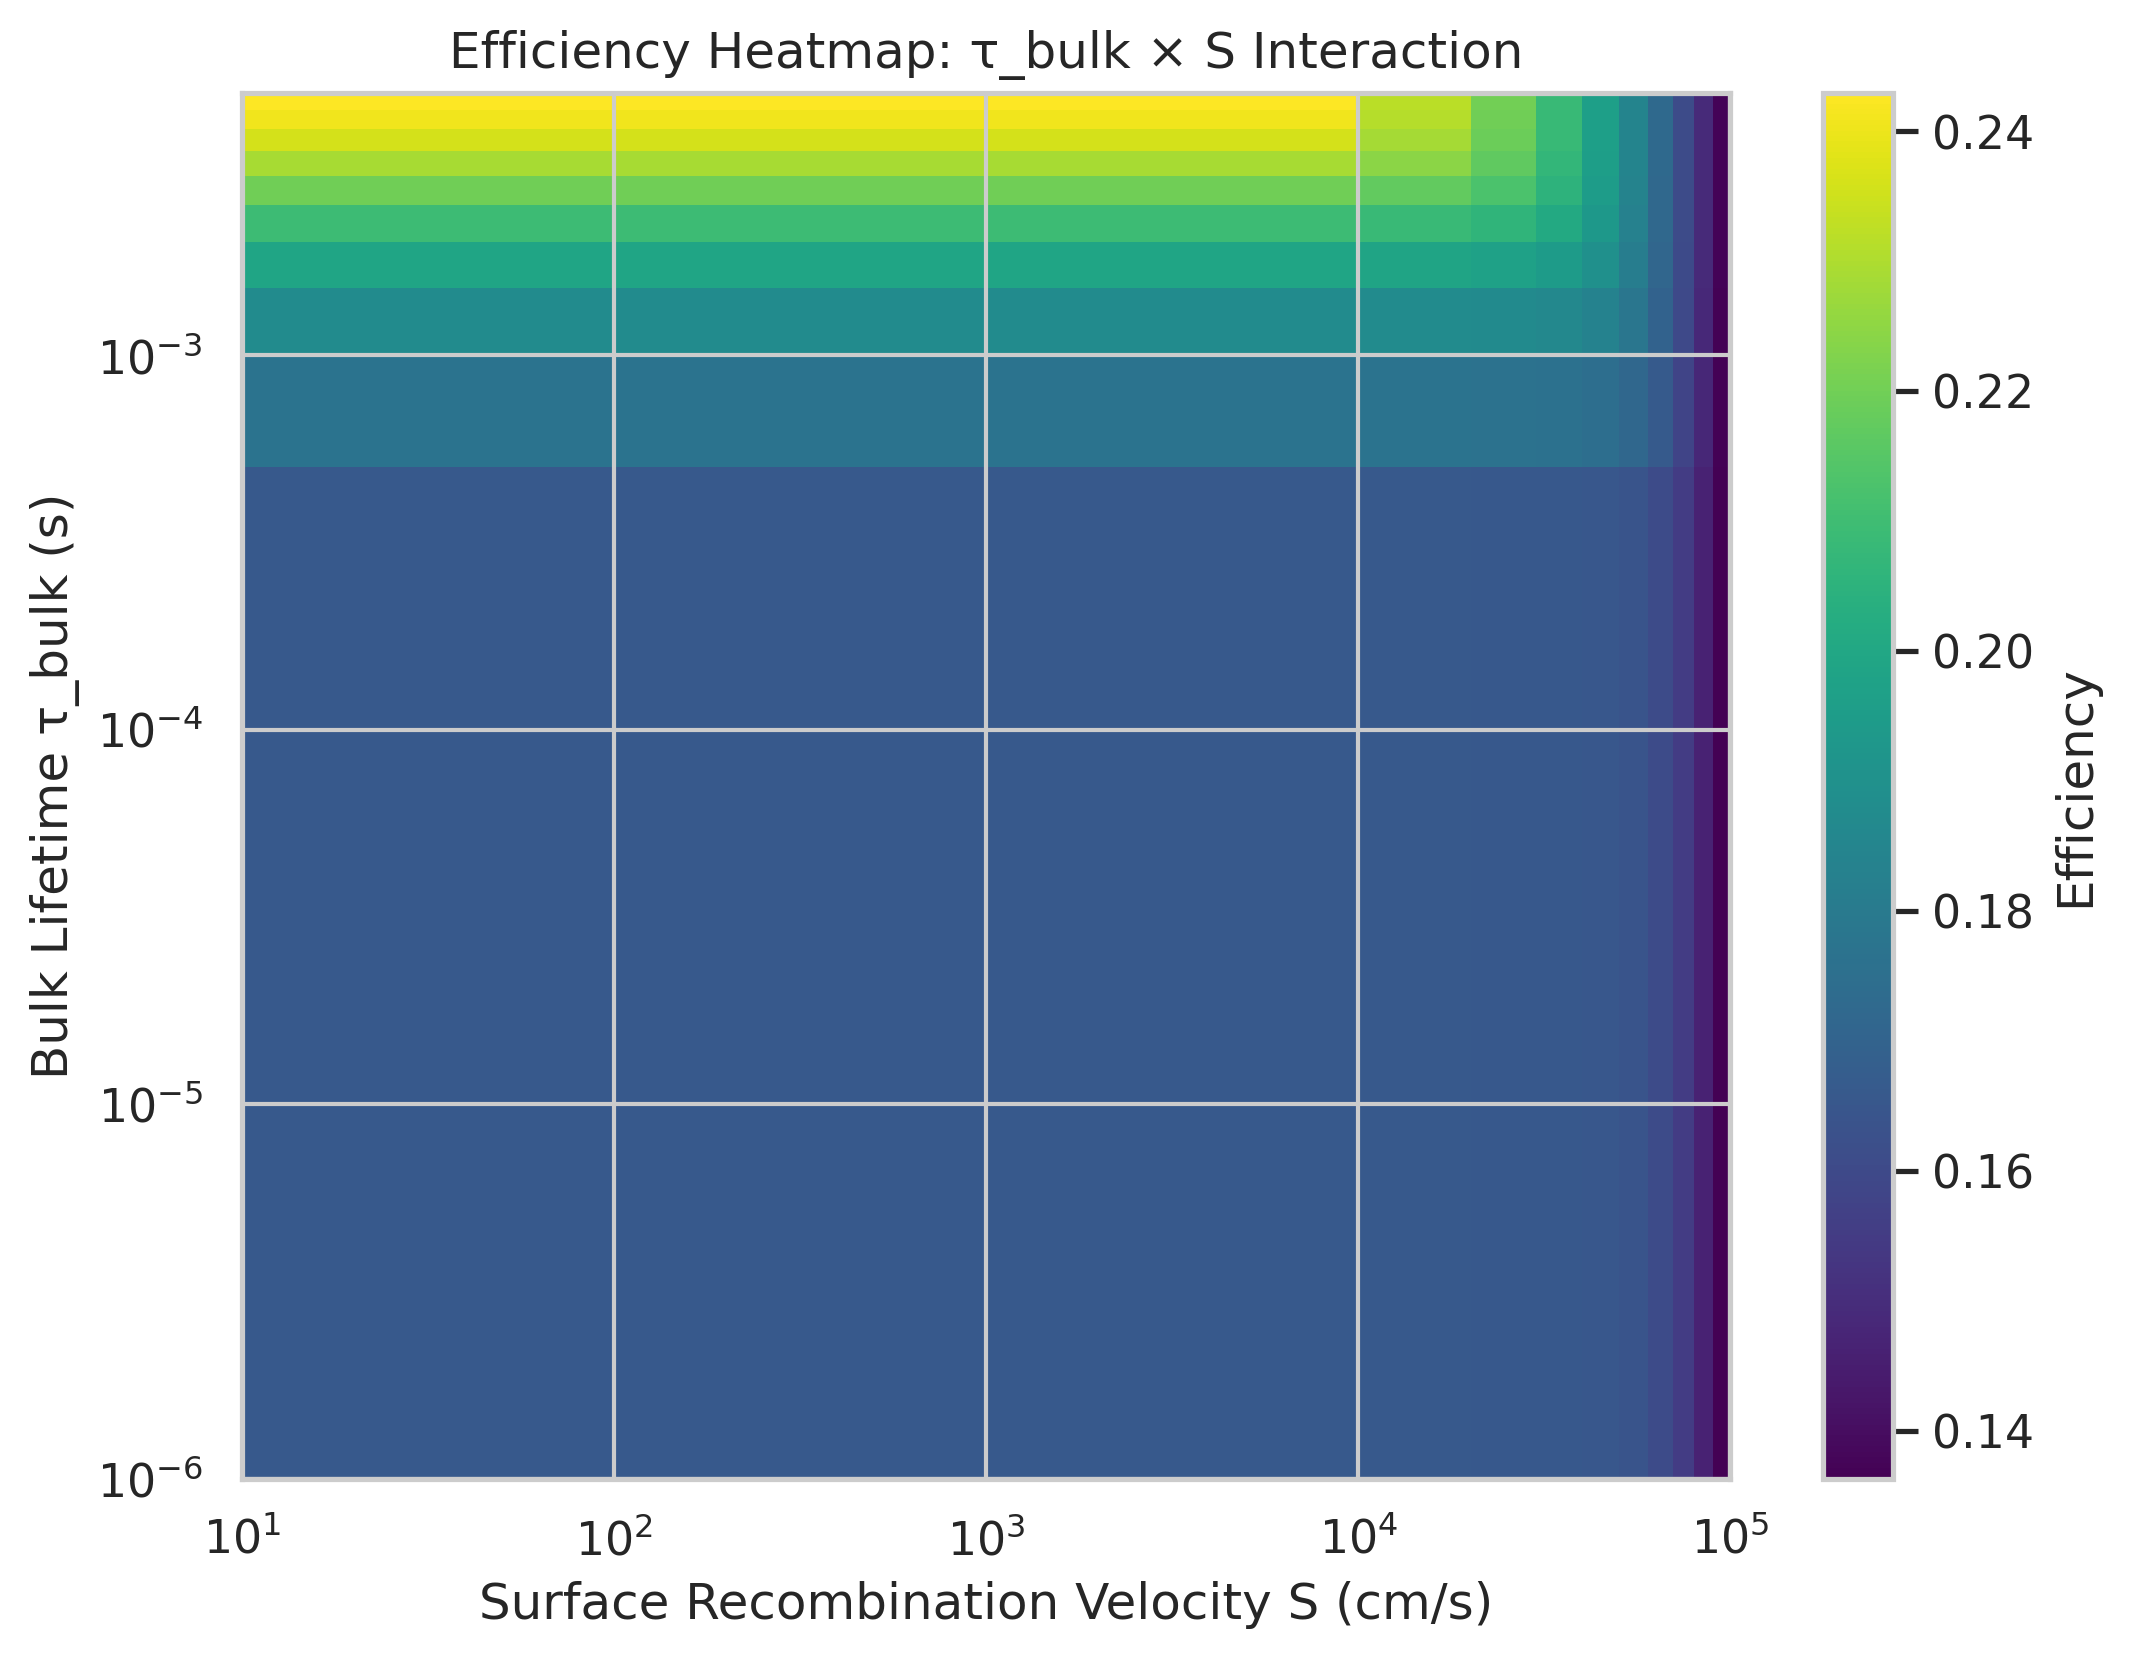

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Fix thickness and doping (same as before)
fixed_W = df["W (um)"].iloc[(df["W (um)"] - 180).abs().argsort()[:1]].values[0]
fixed_Nd = df["Nd (cm^-3)"].iloc[(df["Nd (cm^-3)"] - 1e16).abs().argsort()[:1]].values[0]

# Subset the dataframe
subset = df[(df["W (um)"] == fixed_W) & (df["Nd (cm^-3)"] == fixed_Nd)]

# Create pivot table for heatmap: rows = tau_bulk, cols = S, values = Efficiency
pivot = subset.pivot_table(index="tau_bulk (s)", columns="S (cm/s)", values="Efficiency")

# Plot
plt.figure(figsize=(8,6))
im = plt.imshow(pivot.values, aspect='auto', origin='lower',
                extent=[subset["S (cm/s)"].min(), subset["S (cm/s)"].max(),
                        subset["tau_bulk (s)"].min(), subset["tau_bulk (s)"].max()],
                cmap='viridis')

plt.xscale('log')
plt.yscale('log')
plt.colorbar(im, label='Efficiency')
plt.xlabel("Surface Recombination Velocity S (cm/s)")
plt.ylabel("Bulk Lifetime τ_bulk (s)")
plt.title("Efficiency Heatmap: τ_bulk × S Interaction")
plt.show()

In [17]:
import pandas as pd

# Suppose your dataframe is called df_simulation
df.to_csv('SiliconSolarCell_Data.csv', index=False)
print("Data saved successfully!")

Data saved successfully!
